In [2]:
import os 
import sys
os.chdir('/Users/dagpalmstierna/TQR Project')
sys.path.append(os.path.abspath('/Users/dagpalmstierna/TQR Project/predicters'))
import pandas as pd
from predicters.randomforest import RandomForestModel
from dataloader import DataLoader
from backtest import RandomForestStrategy
import yfinance as yf
import backtrader as bt
import warnings
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning, message=".*Series.fillna with 'method' is deprecated.*")
warnings.filterwarnings("ignore", category=UserWarning, message=".*infer_datetime_format.*")
warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*invalid value encountered in reduce.*")

dl = DataLoader()
rf1 = RandomForestModel()



/Users/dagpalmstierna/TQR Project/predicters/dataloader.py:123: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(f"data/{src}.csv", converters={"Price": lambda x: str(x.replace(",", "."))}, parse_dates=["Date"], date_parser=lambda x: pd.to_datetime(x, format='%m/%d/%Y'), decimal=",")
/opt/anaconda3/envs/Ta-lib/lib/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Users/dagpalmstierna/TQR Project/predicters/dataloader.py:123: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(f"data/{src}.csv", converters={"Price": lambda x: str(x.replace("

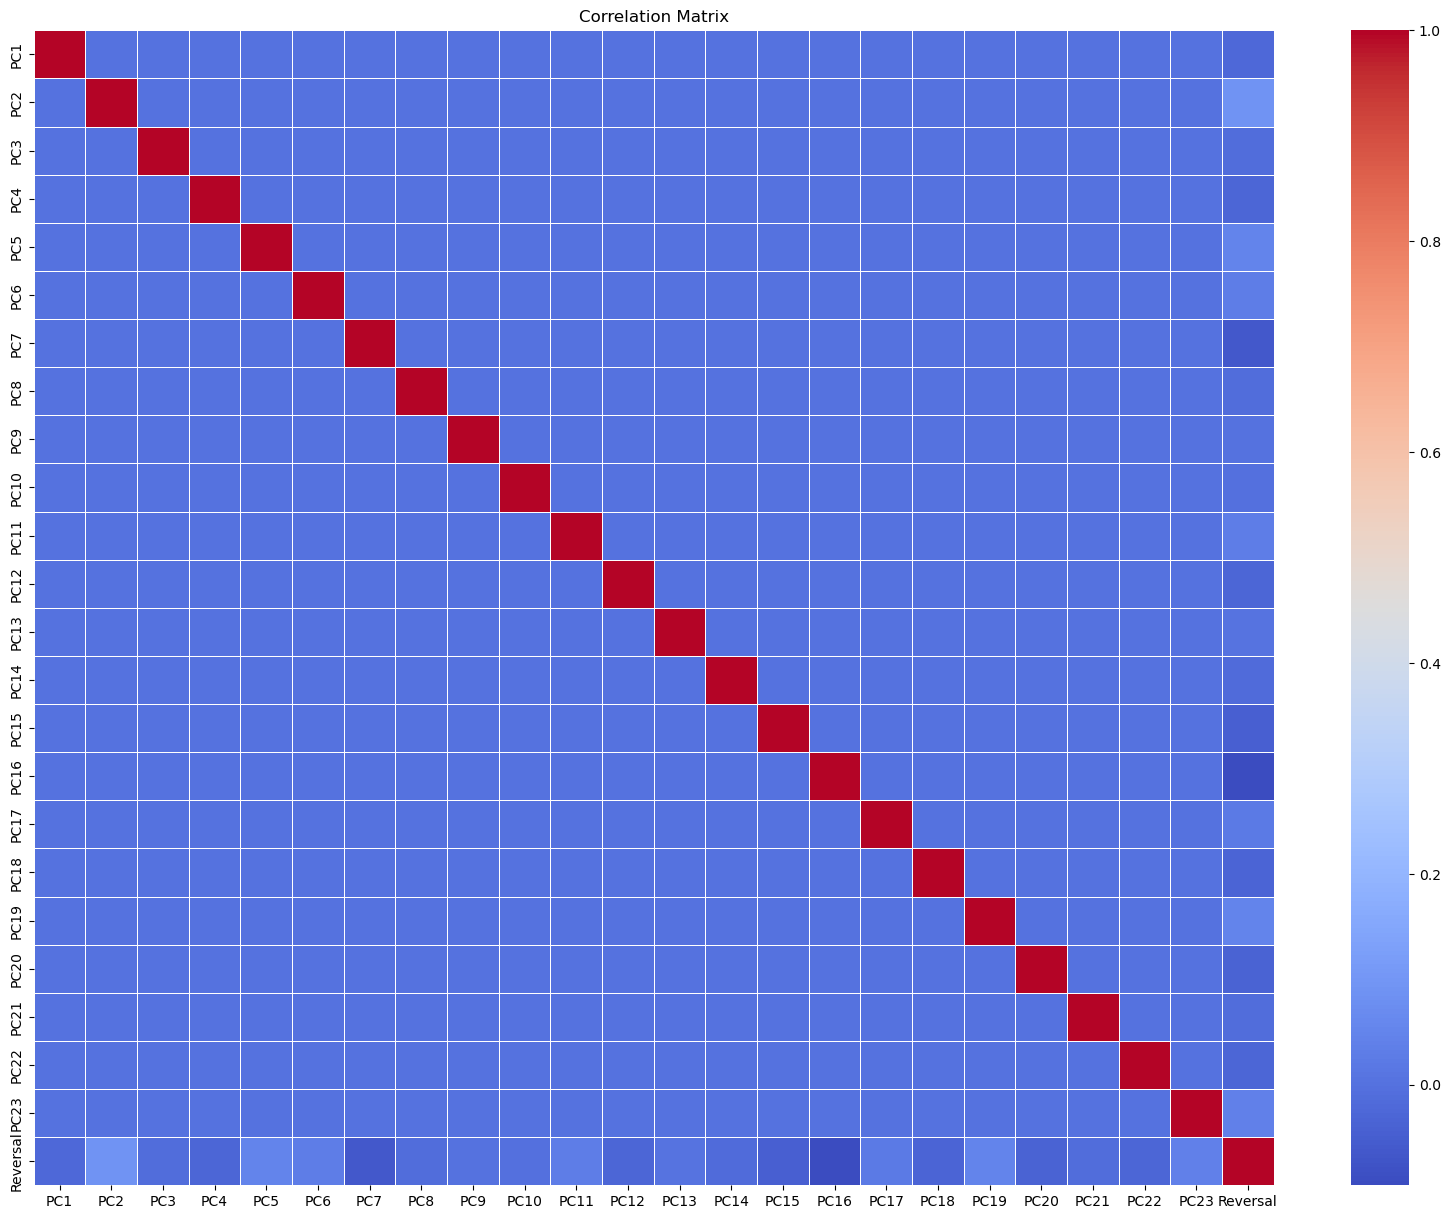

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

def correlation_matrix():
    df = dl.get_data()
    
    numeric_df = df.select_dtypes(include=[np.number])
    corr_matrix = numeric_df.corr()    
    
    plt.figure(figsize=(20, 15))  
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.show()

correlation_matrix()


    

/Users/dagpalmstierna/TQR Project/predicters/randomforest.py:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X.fillna(method='ffill', inplace=True)
/Users/dagpalmstierna/TQR Project/predicters/dataloader.py:145: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  for group_time, group in train_df.groupby(pd.Grouper(freq=window)):


Fold 1
Training data time period: 2010-09-06 00:00:00 to 2012-06-21 00:00:00
Test data time period: 2012-06-25 00:00:00 to 2014-09-15 00:00:00
Reversal
1    175
0    175
Name: count, dtype: int64
Fold 1
Fold 1 - Accuracy: 0.5772, F1-score: 0.7013

Fold 2
Training data time period: 2010-09-06 00:00:00 to 2014-09-15 00:00:00
Test data time period: 2014-09-16 00:00:00 to 2016-09-21 00:00:00
Reversal
1    355
0    355
Name: count, dtype: int64
Fold 2


/Users/dagpalmstierna/TQR Project/predicters/dataloader.py:145: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  for group_time, group in train_df.groupby(pd.Grouper(freq=window)):


Fold 2 - Accuracy: 0.6140, F1-score: 0.7420

Fold 3
Training data time period: 2010-09-06 00:00:00 to 2016-09-21 00:00:00
Test data time period: 2016-09-26 00:00:00 to 2019-02-06 00:00:00
Reversal
1    527
0    527
Name: count, dtype: int64
Fold 3


/Users/dagpalmstierna/TQR Project/predicters/dataloader.py:145: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  for group_time, group in train_df.groupby(pd.Grouper(freq=window)):


Fold 3 - Accuracy: 0.5257, F1-score: 0.6282

Fold 4
Training data time period: 2010-09-06 00:00:00 to 2019-02-06 00:00:00
Test data time period: 2019-02-07 00:00:00 to 2021-03-18 00:00:00
Reversal
1    691
0    691
Name: count, dtype: int64
Fold 4


/Users/dagpalmstierna/TQR Project/predicters/dataloader.py:145: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  for group_time, group in train_df.groupby(pd.Grouper(freq=window)):


Fold 4 - Accuracy: 0.5625, F1-score: 0.6610

Fold 5
Training data time period: 2010-09-06 00:00:00 to 2021-03-18 00:00:00
Test data time period: 2021-03-19 00:00:00 to 2023-03-15 00:00:00
Reversal
1    858
0    858
Name: count, dtype: int64
Fold 5


/Users/dagpalmstierna/TQR Project/predicters/dataloader.py:145: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  for group_time, group in train_df.groupby(pd.Grouper(freq=window)):


Fold 5 - Accuracy: 0.5772, F1-score: 0.6608

Overall accuracy: 0.5713
Overall F1-score: 0.6787
Overall Recall: 0.7436
Aggregated Feature Importances (head):
 feature  importance
    PC8    0.064879
   PC16    0.061371
   PC13    0.054610
    PC4    0.054005
   PC12    0.053219
   PC15    0.052640
    PC6    0.046552
    PC7    0.045680
   PC11    0.042424
    PC1    0.042142
   PC18    0.040686
   PC23    0.040000
   PC20    0.039042
   PC17    0.037931
   PC22    0.037892
    PC9    0.037265
   PC10    0.037157
    PC3    0.036814
   PC21    0.036019
    PC2    0.035433
    PC5    0.035424
   PC19    0.035234
   PC14    0.033579
Aggregated Confusion Matrix:
 [[154 370]
 [213 623]]


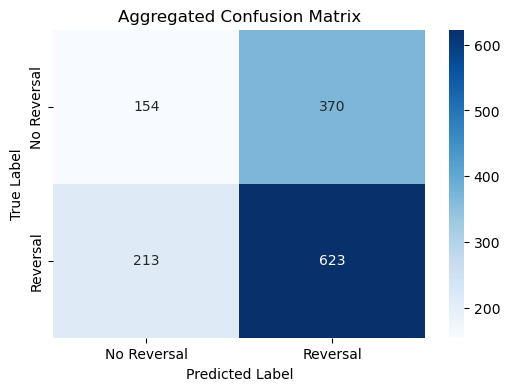

In [4]:
def run_predicter():
   
    rf1.run_model()                  
    rf1.get_overall_results()      

run_predicter()

Series([], Name: count, dtype: int64)


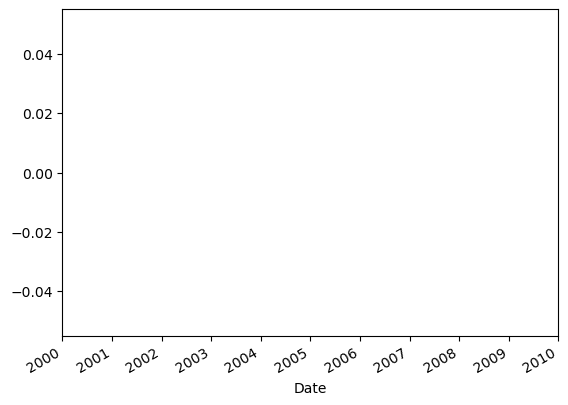

Cumulative Returns:  nan
Sharpe Ratio:  nan
Max Drawdown:  nan
Max Drawdown %:  nan


TypeError: unsupported operand type(s) for -: 'NoneType' and 'NoneType'

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import yfinance as yf
import numpy as np

etf_data = yf.Ticker("IHYG.L").history(start=dl.start, end=dl.end)
etf_data.index = pd.to_datetime(etf_data.index, infer_datetime_format=True, errors='coerce')
etf_data.index = etf_data.index.tz_localize(None)
predictions = rf1.get_predictions()


etf_data["Signal"] = etf_data.index.map(lambda k: predictions.get(k.date()))
#etf_data["Signal"].fillna(0, inplace=True)
print(etf_data["Signal"].value_counts())

def backtest():
    etf_data["Next_Open"] = etf_data["Open"].shift(-1)
    etf_data["Returns"] = etf_data["Signal"] * ((etf_data["Next_Open"] / etf_data["Close"]) - 1) 
    etf_data["Cumulative_Returns"] = (1 + etf_data["Returns"]).cumprod()
    etf_data["Cumulative_Returns"].plot()
   
    plt.show()
    print("Cumulative Returns: ", etf_data["Cumulative_Returns"].iloc[-2])
    print("Sharpe Ratio: ", etf_data["Returns"].mean() / etf_data["Returns"].std() * np.sqrt(252))
    print("Max Drawdown: ", etf_data["Cumulative_Returns"].max() - etf_data["Cumulative_Returns"].min())
    print("Max Drawdown %: ", (etf_data["Cumulative_Returns"].max() - etf_data["Cumulative_Returns"].min()) / etf_data["Cumulative_Returns"].max())
    print("Total Trades: ", np.sum(etf_data["Signal"].diff() != 0))
    print("Winning Trades: ", np.sum(etf_data["Returns"] > 0))
    print("Losing Trades: ", np.sum(etf_data["Returns"] < 0))
    print("Average Trade: ", etf_data["Returns"].mean())
    print("Average Winning Trade: ", etf_data["Returns"][etf_data["Returns"] > 0].mean())
    print("Average Losing Trade: ", etf_data["Returns"][etf_data["Returns"] < 0].mean())
    print("Largest Winning Trade: ", etf_data["Returns"].max())
    print("Largest Losing Trade: ", etf_data["Returns"].min())

backtest()


In [6]:
def run_backtest(model):
    df = rf1.df
    
    volume_series = yf.Ticker("IHYG.L").history(start=dl.start, end=dl.end)["Volume"]
    volume_series.index = volume_series.index.tz_localize(None)

    df["Volume"] = volume_series.reindex(df.index).fillna(0)
    
    vix_series = yf.Ticker("^VIX").history(start=dl.start, end=dl.end)["Close"]
    vix_series.index = vix_series.index.tz_localize(None)

    df["VIX"] = vix_series.reindex(df.index).fillna(0)
    predictions = { key.date(): value for key, value in zip(df.index, rf1.get_predictions())} 

    volatility = { key.date(): value for key, value in zip(df.index, df["VIX"]) }

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    data_feed = bt.feeds.PandasData(dataname=df)

    cerebro = bt.Cerebro()
    cerebro.adddata(data_feed)
    cerebro.broker.setcash(1000000)

    cerebro.broker.set_coo(True)
    cerebro.broker.set_coc(True)

    cerebro.addstrategy(RandomForestStrategy, predictions=predictions, volatility=volatility)

    cerebro.run()
    cerebro.plot()

run_backtest(rf1)







22.510000228881836
2010-09-22 - Date is (2010-09-22) signal is 1 and volatility is 22.510000228881836<=30: Buying at CLOSE: 1000000.0
23.8700008392334
2010-09-23 - Date is (2010-09-23) signal is 1 and volatility is 23.8700008392334<=30: Buying at CLOSE: 1000000.0
21.709999084472656
2010-09-24 - Date is (2010-09-24) signal is 1 and volatility is 21.709999084472656<=30: Buying at CLOSE: 1000000.0
23.25
2010-09-29 - Date is (2010-09-29) signal is 1 and volatility is 23.25<=30: Buying at CLOSE: 1000000.0
21.559999465942383
2010-10-07 - Date is (2010-10-07) signal is 1 and volatility is 21.559999465942383<=30: Buying at CLOSE: 1000000.0
19.8799991607666
2010-10-14 - Date is (2010-10-14) signal is 1 and volatility is 19.8799991607666<=30: Buying at CLOSE: 1000000.0
19.030000686645508
2010-10-15 - Date is (2010-10-15) signal is 1 and volatility is 19.030000686645508<=30: Buying at CLOSE: 1000000.0
19.09000015258789
2010-10-18 - Date is (2010-10-18) signal is 1 and volatility is 19.09000015258

<IPython.core.display.Javascript object>